# Notebook 1 — LIDC Malignancy & Segmentation Mask Extraction

**Amaç:** LUNA16'daki her nodül için LIDC-IDRI'den
- ortalama malignancy rating (4 radyolog konsensüsü)
- 3D segmentasyon mask'ı (≥50% radyolog ortak alanı)

çıkartıp, `candidates.csv` class=1 satırlarıyla **uzamsal eşleştirme** yaparak
fine-tune için tek bir kanonik nodül listesi üretmek.

**Girdiler:**
- `candidates.csv` — LUNA16 candidates
- LUNA16 NPZ dosyaları — `.npz` (her dosya bir scan, ZYX konvansiyonu)
- LIDC-IDRI annotation DB — `pylidc` paketiyle otomatik gelir

**Çıktılar:**
- `nodules.csv` — kanonik nodül listesi (seriesuid, world coord, malignancy_mean, label ∈ {0, 1, NaN}, mask_key)
- `nodule_masks.h5` — her nodül için bbox + 3D bool mask (NPZ ZYX uzayında)

**Çalışma süresi (A100, Colab):** ~20-40 dakika (büyük kısmı mask extraction)


## 1. Dependency kurulumu

`pylidc` LIDC-IDRI annotation'larını parse eder. DICOM dosyalarına ihtiyaç YOKtur — sadece annotation sorgusu yapacağımız için bundled SQLite yeterli.

In [1]:
!pip install pylidc h5py scikit-learn --quiet

# pylidc + NumPy 1.24+ uyumsuzluğu için monkey-patch
# (pylidc iç kodu np.int / np.bool / np.float kullanıyor — deprecated alias'lar)
import numpy as np
for _attr, _builtin in [('int', int), ('float', float), ('bool', bool), ('object', object)]:
    if not hasattr(np, _attr):
        setattr(np, _attr, _builtin)

import pylidc as pl
print(f'pylidc version: {pl.__version__}')
print(f'NumPy compatibility patch: OK')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 102.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 116.5 MB/s eta 0:00:00


/tmp/ipykernel_7732/4235613073.py:7: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, _attr):


pylidc version: 0.2.3
NumPy compatibility patch: OK


## 2. Drive bağlantısı

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 3. pylidc config: DICOM YOK modu

`.pylidcrc` dosyasına `warn = False` yazıyoruz. Annotation queries DICOM olmadan çalışır.

In [3]:
import os
HOME = os.path.expanduser('~')
PYLIDCRC = os.path.join(HOME, '.pylidcrc')
with open(PYLIDCRC, 'w') as f:
    f.write('[dicom]\nwarn = False\n')
print(f'.pylidcrc yazıldı: {PYLIDCRC}')

# Test: LIDC DB'den scan sayısı al
n_scans = pl.query(pl.Scan).count()
n_anns = pl.query(pl.Annotation).count()
print(f'LIDC DB: {n_scans} scan, {n_anns} annotation')
assert n_scans > 1000, 'DB yüklenmedi gibi görünüyor'

.pylidcrc yazıldı: /root/.pylidcrc
LIDC DB: 1018 scan, 6859 annotation


## 4. Yollar ve parametreler

**ÖNEMLİ:** Aşağıdaki path'leri kendi Drive yapına göre düzelt.

In [4]:
# === GİRDİLER ===
CANDIDATES_CSV = '/content/drive/MyDrive/bitirme/Dataset/candidates.csv'
NPZ_DIR = '/content/drive/MyDrive/bitirme/LUNA_Processed'

# === ÇIKTILAR ===
OUTPUT_DIR = '/content/drive/MyDrive/bitirme/Finetune_Labels'
NODULES_CSV = os.path.join(OUTPUT_DIR, 'nodules.csv')
MASKS_H5    = os.path.join(OUTPUT_DIR, 'nodule_masks.h5')

# === PARAMETRELER ===
# Bir LIDC nodülünü LUNA16 candidate cluster'ı ile eşleşmiş saymak için max mesafe
SPATIAL_MATCH_THRESHOLD_MM = 10.0

# candidates.csv class=1'leri scan içinde aynı nodüle ait kabul etmek için max mesafe
CANDIDATES_CLUSTER_THRESHOLD_MM = 10.0

# Malignancy threshold'ları (kullanıcı kararı)
BENIGN_UPPER = 2.5   # ortalama ≤2.5 → benign (label=0)
MALIGN_LOWER = 3.5   # ortalama ≥3.5 → malign (label=1)
# 2.5 < ortalama < 3.5 → ambiguous → label=NaN (malign/benign task'tan drop)

# LIDC nodülünü kabul etmek için minimum radyolog sayısı
# LUNA16 reference standard = ≥3/4 radyolog. Bunu izliyoruz.
MIN_RADIOLOGISTS = 3

# Segmentasyon consensus seviyesi (0.5 = en az yarısı + 1 radyolog ortak alan)
# pylidc.utils.consensus için clevel parametresi
CONSENSUS_CLEVEL = 0.5

os.makedirs(OUTPUT_DIR, exist_ok=True)
print('Konfigürasyon OK')
print(f'  Çıktı dizini: {OUTPUT_DIR}')

Konfigürasyon OK
  Çıktı dizini: /content/drive/MyDrive/bitirme/Finetune_Labels


## 5. candidates.csv class=1 satırlarını cluster'la

Aynı nodül için birden fazla candidate satırı olabilir (typical %12 duplicate). DBSCAN ile 10mm threshold'unda cluster'layıp her gerçek nodülü tek satıra indir.

In [5]:
import pandas as pd
import numpy as np
from sklearn.cluster import DBSCAN

print('candidates.csv yükleniyor...')
df_cand = pd.read_csv(CANDIDATES_CSV)
print(f'  Toplam satır: {len(df_cand):,}')
print(f'  Unique seriesuid: {df_cand["seriesuid"].nunique()}')

positives = df_cand[df_cand['class'] == 1].copy()
print(f'  Ham pozitif (class=1): {len(positives)}')

# Scan içinde DBSCAN cluster
def cluster_within_scan(group, eps=CANDIDATES_CLUSTER_THRESHOLD_MM):
    coords = group[['coordX', 'coordY', 'coordZ']].values
    if len(coords) == 1:
        return pd.DataFrame([{
            'coordX': coords[0][0],
            'coordY': coords[0][1],
            'coordZ': coords[0][2],
            'n_candidates': 1,
        }])
    db = DBSCAN(eps=eps, min_samples=1).fit(coords)
    labels = db.labels_
    result = []
    for cid in np.unique(labels):
        m = labels == cid
        center = coords[m].mean(axis=0)
        result.append({
            'coordX': center[0],
            'coordY': center[1],
            'coordZ': center[2],
            'n_candidates': int(m.sum()),
        })
    return pd.DataFrame(result)

luna_nodules = (positives
    .groupby('seriesuid', group_keys=True)
    .apply(cluster_within_scan, include_groups=False)
    .reset_index(level=0)
    .reset_index(drop=True))

print(f'  Cluster sonrası biricik nodül: {len(luna_nodules)}')
print(f'  Multi-candidate nodül: {(luna_nodules["n_candidates"] > 1).sum()}')
luna_nodules.head()

candidates.csv yükleniyor...
  Toplam satır: 551,065
  Unique seriesuid: 888
  Ham pozitif (class=1): 1351
  Cluster sonrası biricik nodül: 1151
  Multi-candidate nodül: 116


,seriesuid,coordX,coordY,coordZ,n_candidates
0,1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222...,104.164804,-211.685591,-227.011364,1
1,1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222...,-128.940000,-175.040000,-297.870000,1
2,1.3.6.1.4.1.14519.5.2.1.6279.6001.100398138793...,70.190000,-140.930000,877.680000,1
3,1.3.6.1.4.1.14519.5.2.1.6279.6001.100621383016...,89.096247,194.261837,-515.606978,2
4,1.3.6.1.4.1.14519.5.2.1.6279.6001.100621383016...,90.039117,149.350422,-427.353622,4


## 6. LIDC scanlerinden malignancy + centroid çıkar

Her LIDC scan için:
- `cluster_annotations()` ile farklı radyologların aynı nodüle ait annotation'larını grupla
- Her grup için 4 radyologun ortalama malignancy'sini al
- Centroid'i image space'te al (row, col, slice) — sonra NPZ origin/spacing ile world'e çevireceğiz

**~5-10 dakika** alır (1018 scan × ortalama 2.5 nodül).

In [6]:
from tqdm.auto import tqdm

print('LIDC nodule extraction başlıyor...')
all_scans = pl.query(pl.Scan).all()
print(f'  Toplam LIDC scan: {len(all_scans)}')

lidc_rows = []
n_skipped = 0

for scan in tqdm(all_scans, desc='LIDC scans'):
    seriesuid = scan.series_instance_uid
    try:
        clusters = scan.cluster_annotations()
    except Exception as e:
        n_skipped += 1
        continue

    for nod_idx, cluster in enumerate(clusters):
        if len(cluster) == 0:
            continue

        mal_ratings = [a.malignancy for a in cluster]
        centroids = np.array([a.centroid for a in cluster])
        # pylidc Annotation.centroid → (row, col, slice) per docs
        centroid_mean = centroids.mean(axis=0)

        diameters = [a.diameter for a in cluster]

        lidc_rows.append({
            'seriesuid': seriesuid,
            'lidc_nodule_idx': nod_idx,
            # image coords (pylidc convention)
            'centroid_row': float(centroid_mean[0]),
            'centroid_col': float(centroid_mean[1]),
            'centroid_slice': float(centroid_mean[2]),
            # ratings
            'malignancy_mean': float(np.mean(mal_ratings)),
            'malignancy_std': float(np.std(mal_ratings)),
            'n_radiologists': len(cluster),
            'diameter_mm': float(max(diameters)),
            # for later mask extraction
            'annotation_ids': ','.join(str(a.id) for a in cluster),
        })

lidc_df = pd.DataFrame(lidc_rows)
print(f'\nToplam LIDC nodule cluster: {len(lidc_df)}')
print(f'  ≥3 radyolog (LUNA16 reference): {(lidc_df["n_radiologists"]>=3).sum()}')
print(f'  Skipped scans: {n_skipped}')
print(f'\nRadyolog sayısı dağılımı:')
print(lidc_df["n_radiologists"].value_counts().sort_index())
print(f'\nMalignancy mean dağılımı:')
print(lidc_df["malignancy_mean"].describe())

LIDC nodule extraction başlıyor...
  Toplam LIDC scan: 1018


LIDC scans:   0%|          | 0/1018 [00:00<?, ?it/s]

Failed to reduce all groups to <= 4 Annotations.
Some nodules may be close and must be grouped manually.
Failed to reduce all groups to <= 4 Annotations.
Some nodules may be close and must be grouped manually.
Failed to reduce all groups to <= 4 Annotations.
Some nodules may be close and must be grouped manually.
Failed to reduce all groups to <= 4 Annotations.
Some nodules may be close and must be grouped manually.
Failed to reduce all groups to <= 4 Annotations.
Some nodules may be close and must be grouped manually.
Failed to reduce all groups to <= 4 Annotations.
Some nodules may be close and must be grouped manually.
Failed to reduce all groups to <= 4 Annotations.
Some nodules may be close and must be grouped manually.
Failed to reduce all groups to <= 4 Annotations.
Some nodules may be close and must be grouped manually.
Failed to reduce all groups to <= 4 Annotations.
Some nodules may be close and must be grouped manually.
Failed to reduce all groups to <= 4 Annotations.
Some n

## 7. Image coord → world coord (NPZ origin/spacing ile)

LIDC nodülünü LUNA16 candidate ile eşleştirmek için world (mm) coord'a ihtiyacımız var. pylidc image coord verir; NPZ'nin origin + spacing'i ile world'e çeviriyoruz.

**Konvansiyon kontrolü:**
- pylidc `centroid` → (row, col, slice) yani (i, j, k)
- NPZ `scan.shape` → (Z, Y, X) yani (slice, row, col)
- NPZ `origin`, `spacing` → bizim test ettiğimize göre **ZYX order** (spacing[0]=2.5 slice thickness olduğundan)
- candidates.csv `coordX/Y/Z` → DICOM standardı X, Y, Z

Dönüşüm:
```
world_z = origin[0] + slice * spacing[0]
world_y = origin[1] + row   * spacing[1]
world_x = origin[2] + col   * spacing[2]
```

In [7]:
def npz_path_for(seriesuid):
    '''İki olası isim varyasyonunu dene: nokta veya alt-tire ile.'''
    p1 = os.path.join(NPZ_DIR, f'{seriesuid}.npz')
    if os.path.exists(p1):
        return p1
    p2 = os.path.join(NPZ_DIR, seriesuid.replace('.', '_') + '.npz')
    if os.path.exists(p2):
        return p2
    return None


def image_to_world(seriesuid, row_i, col_j, slice_k):
    '''Image coord (i, j, k) → world (x, y, z) NPZ origin/spacing kullanarak.'''
    p = npz_path_for(seriesuid)
    if p is None:
        return None
    try:
        # mmap_mode ile sadece header oku, tüm scan'i RAM'e almaya gerek yok
        data = np.load(p)
        origin = data['origin']    # ZYX
        spacing = data['spacing']  # ZYX
    except Exception:
        return None
    world_z = origin[0] + slice_k * spacing[0]
    world_y = origin[1] + row_i   * spacing[1]
    world_x = origin[2] + col_j   * spacing[2]
    return (world_x, world_y, world_z)


# Her LIDC nodülü için world coord ekle
print('Image → World dönüşümü...')
world_x, world_y, world_z = [], [], []
npz_found = 0
for _, r in tqdm(lidc_df.iterrows(), total=len(lidc_df)):
    wc = image_to_world(r['seriesuid'], r['centroid_row'], r['centroid_col'], r['centroid_slice'])
    if wc is None:
        world_x.append(np.nan); world_y.append(np.nan); world_z.append(np.nan)
    else:
        world_x.append(wc[0]); world_y.append(wc[1]); world_z.append(wc[2])
        npz_found += 1

lidc_df['world_x'] = world_x
lidc_df['world_y'] = world_y
lidc_df['world_z'] = world_z

print(f'\nNPZ bulunan nodule: {npz_found}/{len(lidc_df)}')
print(f'  (LIDC 1018 scan içerir, LUNA16 888. Fark normal)')

Image → World dönüşümü...


  0%|          | 0/2651 [00:00<?, ?it/s]


NPZ bulunan nodule: 2277/2651
  (LIDC 1018 scan içerir, LUNA16 888. Fark normal)


## 8. Spatial nearest-neighbor matching

Her LUNA16 nodule cluster için aynı scan içindeki en yakın LIDC nodülünü bul. Mesafe ≤10mm ise eşleştir, değilse "no match" işaretle.

In [8]:
from scipy.spatial import cKDTree

# Sadece geçerli world coord + yeterli radyolog filtresi
valid_lidc = lidc_df.dropna(subset=['world_x', 'world_y', 'world_z']).copy()
valid_lidc = valid_lidc[valid_lidc['n_radiologists'] >= MIN_RADIOLOGISTS].copy()
print(f'Geçerli LIDC nodule (NPZ + ≥{MIN_RADIOLOGISTS} radyolog): {len(valid_lidc)}')

# Scan-by-scan matching
matched = []
unmatched = []

luna_grouped = luna_nodules.groupby('seriesuid')
for seriesuid, luna_group in tqdm(luna_grouped, total=luna_nodules['seriesuid'].nunique(),
                                    desc='Matching'):
    lidc_in_scan = valid_lidc[valid_lidc['seriesuid'] == seriesuid]

    if len(lidc_in_scan) == 0:
        for _, lr in luna_group.iterrows():
            unmatched.append({**lr.to_dict(), 'reason': 'no_valid_lidc_in_scan'})
        continue

    lidc_coords = lidc_in_scan[['world_x', 'world_y', 'world_z']].values
    tree = cKDTree(lidc_coords)

    for _, lr in luna_group.iterrows():
        target = np.array([lr['coordX'], lr['coordY'], lr['coordZ']])
        dist, nn_idx = tree.query(target)

        if dist <= SPATIAL_MATCH_THRESHOLD_MM:
            lm = lidc_in_scan.iloc[nn_idx]
            matched.append({
                'seriesuid': seriesuid,
                'coordX': lr['coordX'],
                'coordY': lr['coordY'],
                'coordZ': lr['coordZ'],
                'n_candidates': int(lr['n_candidates']),
                # LIDC info
                'lidc_nodule_idx': int(lm['lidc_nodule_idx']),
                'malignancy_mean': float(lm['malignancy_mean']),
                'malignancy_std': float(lm['malignancy_std']),
                'n_radiologists': int(lm['n_radiologists']),
                'diameter_mm': float(lm['diameter_mm']),
                'match_distance_mm': float(dist),
                'annotation_ids': lm['annotation_ids'],
            })
        else:
            unmatched.append({**lr.to_dict(), 'reason': f'nearest_too_far_{dist:.1f}mm'})

matched_df = pd.DataFrame(matched)
unmatched_df = pd.DataFrame(unmatched)

print(f'\n=== MATCHING SONUÇ ===')
print(f'Toplam LUNA16 nodule: {len(luna_nodules)}')
print(f'  Eşleşen:    {len(matched_df)}')
print(f'  Eşleşmeyen: {len(unmatched_df)}')
if len(unmatched_df) > 0:
    print(f'\nEşleşmeme sebepleri:')
    print(unmatched_df['reason'].apply(lambda s: s.split('_')[0:3]).apply(lambda l: '_'.join(l)).value_counts())

print(f'\nMatch distance (mm) istatistikleri:')
print(matched_df['match_distance_mm'].describe())

Geçerli LIDC nodule (NPZ + ≥3 radyolog): 1184


Matching:   0%|          | 0/590 [00:00<?, ?it/s]


=== MATCHING SONUÇ ===
Toplam LUNA16 nodule: 1151
  Eşleşen:    1100
  Eşleşmeyen: 51

Eşleşmeme sebepleri:
reason
nearest_too_far    49
no_valid_lidc       2
Name: count, dtype: int64

Match distance (mm) istatistikleri:
count    1100.000000
mean        1.456203
std         1.223020
min         0.060893
25%         0.689081
50%         1.138130
75%         1.793153
max         9.845695
Name: match_distance_mm, dtype: float64


## 9. Malignancy label uygula

Threshold:
- ≤2.5 → benign (label = 0)
- ≥3.5 → malign (label = 1)
- 2.5–3.5 → ambiguous (label = NaN, malign/benign task'tan drop)

=== MALIGNANCY DAĞILIMI ===
Benign (0–2.5):            327  (29.7%)
Ambiguous (2.5–3.5, drop):   460  (41.8%)
Malign (3.5–5):            313  (28.5%)
Toplam:                  1100

Malign/Benign training için: 640 nodule


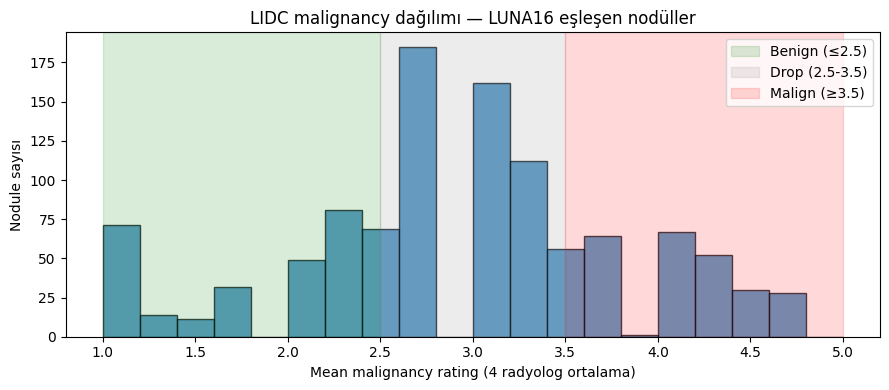

In [9]:
def to_label(m):
    if pd.isna(m): return np.nan
    if m <= BENIGN_UPPER: return 0
    if m >= MALIGN_LOWER: return 1
    return np.nan  # ambiguous

matched_df['malignancy_label'] = matched_df['malignancy_mean'].apply(to_label)

n_benign = (matched_df['malignancy_label'] == 0).sum()
n_malign = (matched_df['malignancy_label'] == 1).sum()
n_ambig = matched_df['malignancy_label'].isna().sum()

print('=== MALIGNANCY DAĞILIMI ===')
print(f'Benign (0–{BENIGN_UPPER}):           {n_benign:>4d}  ({n_benign/len(matched_df)*100:.1f}%)')
print(f'Ambiguous ({BENIGN_UPPER}–{MALIGN_LOWER}, drop):  {n_ambig:>4d}  ({n_ambig/len(matched_df)*100:.1f}%)')
print(f'Malign ({MALIGN_LOWER}–5):           {n_malign:>4d}  ({n_malign/len(matched_df)*100:.1f}%)')
print(f'Toplam:                  {len(matched_df):>4d}')
print(f'\nMalign/Benign training için: {n_benign + n_malign} nodule')

# Histogram
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(matched_df['malignancy_mean'].dropna(), bins=np.arange(1, 5.1, 0.2),
        edgecolor='black', alpha=0.7)
ax.axvspan(1, BENIGN_UPPER, alpha=0.15, color='green', label=f'Benign (≤{BENIGN_UPPER})')
ax.axvspan(BENIGN_UPPER, MALIGN_LOWER, alpha=0.15, color='gray', label=f'Drop ({BENIGN_UPPER}-{MALIGN_LOWER})')
ax.axvspan(MALIGN_LOWER, 5, alpha=0.15, color='red', label=f'Malign (≥{MALIGN_LOWER})')
ax.set_xlabel('Mean malignancy rating (4 radyolog ortalama)')
ax.set_ylabel('Nodule sayısı')
ax.set_title('LIDC malignancy dağılımı — LUNA16 eşleşen nodüller')
ax.legend()
plt.tight_layout()
plt.show()

## 10. Segmentasyon mask çıkartma

Her eşleşen nodül için `pylidc.utils.consensus(annotations, clevel=0.5)` ile 3D bool mask'ı al. Bu mask sadece **bounding box** içinde — tüm scan boyutunda zeros + bbox region şeklinde saklayacağız (memory tasarrufu için).

H5 dosya yapısı:
```
nodule_masks.h5
├── {seriesuid}_nod{idx}/
│   ├── mask    # uint8, shape (z_extent, y_extent, x_extent)
│   └── attrs   # z_start, z_stop, y_start, y_stop, x_start, x_stop
```

Dataset class'ında patch çıkartırken: full mask = zeros_like(scan); full_mask[z_slice, y_slice, x_slice] = mask

**~15-25 dakika** alır.

In [11]:
import h5py
from pylidc.utils import consensus

print(f'Mask extraction başlıyor → {MASKS_H5}')

mask_keys, mask_voxels, has_masks, bbox_strs, mask_reasons = [], [], [], [], []

with h5py.File(MASKS_H5, 'w') as h5f:
    h5f.attrs['clevel'] = CONSENSUS_CLEVEL
    h5f.attrs['note'] = 'Mask is in NPZ voxel space (Z, Y, X). Bbox attrs define location.'

    for _, row in tqdm(matched_df.iterrows(), total=len(matched_df), desc='Masks'):
        seriesuid = row['seriesuid']
        nod_idx = int(row['lidc_nodule_idx'])
        ann_ids = [int(x) for x in row['annotation_ids'].split(',')]

        anns = []
        for aid in ann_ids:
            a = pl.query(pl.Annotation).filter(pl.Annotation.id == aid).first()
            if a is not None:
                anns.append(a)

        if len(anns) == 0:
            has_masks.append(False); mask_keys.append(None); mask_voxels.append(0)
            bbox_strs.append(None); mask_reasons.append('no_annotations_loaded')
            continue

        try:
            # 🔧 FIX: ret_masks=False ile sadece 2 değer döner (mask, bbox)
            cmask, cbbox = consensus(anns, clevel=CONSENSUS_CLEVEL, pad=0, ret_masks=False)

            row_slc, col_slc, slc_slc = cbbox

            # pylidc convention: (rows, cols, slices) → NPZ convention: (slices, rows, cols)
            cmask_zyx = np.transpose(cmask, (2, 0, 1)).astype(np.uint8)

            key = f'{seriesuid}_nod{nod_idx}'
            grp = h5f.create_group(key)
            grp.create_dataset('mask', data=cmask_zyx, compression='gzip', compression_opts=4)
            grp.attrs['z_start'] = int(slc_slc.start)
            grp.attrs['z_stop']  = int(slc_slc.stop)
            grp.attrs['y_start'] = int(row_slc.start)
            grp.attrs['y_stop']  = int(row_slc.stop)
            grp.attrs['x_start'] = int(col_slc.start)
            grp.attrs['x_stop']  = int(col_slc.stop)
            grp.attrs['n_annotations'] = len(anns)
            grp.attrs['clevel'] = CONSENSUS_CLEVEL

            has_masks.append(True)
            mask_keys.append(key)
            mask_voxels.append(int(cmask_zyx.sum()))
            bbox_strs.append(f'{slc_slc.start}:{slc_slc.stop},{row_slc.start}:{row_slc.stop},{col_slc.start}:{col_slc.stop}')
            mask_reasons.append(None)

        except Exception as e:
            has_masks.append(False); mask_keys.append(None); mask_voxels.append(0)
            bbox_strs.append(None); mask_reasons.append(str(e)[:120])

matched_df['has_mask'] = has_masks
matched_df['mask_key'] = mask_keys
matched_df['mask_voxel_count'] = mask_voxels
matched_df['bbox_zyx'] = bbox_strs
matched_df['mask_fail_reason'] = mask_reasons

n_mask = matched_df['has_mask'].sum()
print(f'\n=== MASK SONUÇ ===')
print(f'Başarılı:  {n_mask} / {len(matched_df)}')
print(f'Başarısız: {len(matched_df) - n_mask}')

if (len(matched_df) - n_mask) > 0:
    print('\nBaşarısızlık sebepleri:')
    print(matched_df.loc[~matched_df['has_mask'], 'mask_fail_reason'].value_counts().head())

# 🔧 FIX: NaN-safe stats
if n_mask > 0:
    print(f'\nMask voxel count istatistikleri:')
    voxel_stats = matched_df.loc[matched_df['has_mask'], 'mask_voxel_count'].describe()
    print(voxel_stats.round(0).astype(int))
else:
    print('\n⚠️ Hiç mask oluşturulamadı, istatistik yok')

Mask extraction başlıyor → /content/drive/MyDrive/bitirme/Finetune_Labels/nodule_masks.h5


Masks:   0%|          | 0/1100 [00:00<?, ?it/s]


=== MASK SONUÇ ===
Başarılı:  1094 / 1100
Başarısız: 6

Başarısızlık sebepleri:
mask_fail_reason
Unable to synchronously create group (name already exists)    6
Name: count, dtype: int64

Mask voxel count istatistikleri:
count     1094
mean      1033
std       2166
min         20
25%        120
50%        258
75%        785
max      22140
Name: mask_voxel_count, dtype: int64


## 11. Final CSV'yi kaydet

Kolon düzeni training pipeline için optimize.

In [12]:
final_cols = [
    # Identity
    'seriesuid', 'lidc_nodule_idx',
    # World coord (candidates.csv ile aynı konvansiyon: X, Y, Z mm)
    'coordX', 'coordY', 'coordZ',
    # Nodule properties
    'diameter_mm',
    # Malignancy
    'malignancy_mean', 'malignancy_std', 'n_radiologists', 'malignancy_label',
    # Mask
    'has_mask', 'mask_key', 'mask_voxel_count', 'bbox_zyx',
    # Provenance
    'n_candidates', 'match_distance_mm', 'annotation_ids',
]

final_df = matched_df[final_cols].copy()
final_df.to_csv(NODULES_CSV, index=False)
print(f'✅ Kaydedildi: {NODULES_CSV}')
print(f'   {len(final_df)} satır × {len(final_cols)} kolon')
print(f'\nİlk 5 satır:')
final_df.head()

✅ Kaydedildi: /content/drive/MyDrive/bitirme/Finetune_Labels/nodules.csv
   1100 satır × 17 kolon

İlk 5 satır:


,seriesuid,lidc_nodule_idx,coordX,coordY,coordZ,diameter_mm,malignancy_mean,malignancy_std,n_radiologists,malignancy_label,has_mask,mask_key,mask_voxel_count,bbox_zyx,n_candidates,match_distance_mm,annotation_ids
0,1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222...,1,104.164804,-211.685591,-227.011364,6.445312,2.333333,0.942809,3,0.0,True,1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222...,60,"117:119,151:160,401:411",1,0.405075,"4582,4583,4585"
1,1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222...,0,-128.940000,-175.040000,-297.870000,7.348787,3.000000,1.000000,4,NaN,True,1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222...,122,"76:80,206:218,39:52",1,0.586194,"4581,4584,4586,4587"
2,1.3.6.1.4.1.14519.5.2.1.6279.6001.100398138793...,1,70.190000,-140.930000,877.680000,10.915156,2.666667,1.247219,3,NaN,True,1.3.6.1.4.1.14519.5.2.1.6279.6001.100398138793...,140,"88:91,264:277,377:394",1,1.185186,"5723,5725,5726"
3,1.3.6.1.4.1.14519.5.2.1.6279.6001.100621383016...,0,89.096247,194.261837,-515.606978,19.984871,3.750000,1.299038,4,1.0,True,1.3.6.1.4.1.14519.5.2.1.6279.6001.100621383016...,7897,"132:154,321:358,360:396",2,2.533301,"4568,4569,4576,4579"
4,1.3.6.1.4.1.14519.5.2.1.6279.6001.100621383016...,1,90.039117,149.350422,-427.353622,22.279537,3.750000,1.299038,4,1.0,True,1.3.6.1.4.1.14519.5.2.1.6279.6001.100621383016...,11409,"218:244,233:273,359:400",4,1.675889,"4567,4570,4575,4580"


## 12. Özet ve sanity check

In [13]:
print('=' * 60)
print('NOTEBOOK 1 — ÖZET')
print('=' * 60)
print(f'\nÇıktı dosyalar:')
print(f'  📄 {NODULES_CSV}')
print(f'     ({os.path.getsize(NODULES_CSV)/1024:.1f} KB)')
print(f'  📦 {MASKS_H5}')
print(f'     ({os.path.getsize(MASKS_H5)/(1024*1024):.1f} MB)')

print(f'\n📊 Nodul sayıları:')
print(f'  Toplam eşleşen LUNA16 nodul:  {len(final_df)}')
print(f'  ├─ Benign (label=0):           {(final_df["malignancy_label"]==0).sum()}')
print(f'  ├─ Malign (label=1):           {(final_df["malignancy_label"]==1).sum()}')
print(f'  └─ Belirsiz (label=NaN, drop): {final_df["malignancy_label"].isna().sum()}')
print(f'  Mask başarılı:                 {final_df["has_mask"].sum()} / {len(final_df)}')

print(f'\n🎯 Fine-tune için kullanılabilir set:')
n_det = len(final_df)
n_cls = ((final_df['malignancy_label'].notna())).sum()
n_seg = final_df['has_mask'].sum()
n_all = ((final_df['malignancy_label'].notna()) & final_df['has_mask']).sum()
print(f'  Detection (binary, hepsi):      {n_det} nodul')
print(f'  Malignancy classification:      {n_cls} nodul')
print(f'  Segmentation:                   {n_seg} nodul')
print(f'  Üç task da kullanılabilir:      {n_all} nodul')

print(f'\n📁 Sıradaki notebook için:')
print(f'  Notebook 2 bu CSV ve H5 dosyalarını okuyacak,')
print(f'  candidates.csv class=0 negatives ile birleştirip')
print(f'  Dataset class\'ını kuracak.')

NOTEBOOK 1 — ÖZET

Çıktı dosyalar:
  📄 /content/drive/MyDrive/bitirme/Finetune_Labels/nodules.csv
     (311.8 KB)
  📦 /content/drive/MyDrive/bitirme/Finetune_Labels/nodule_masks.h5
     (5.6 MB)

📊 Nodul sayıları:
  Toplam eşleşen LUNA16 nodul:  1100
  ├─ Benign (label=0):           327
  ├─ Malign (label=1):           313
  └─ Belirsiz (label=NaN, drop): 460
  Mask başarılı:                 1094 / 1100

🎯 Fine-tune için kullanılabilir set:
  Detection (binary, hepsi):      1100 nodul
  Malignancy classification:      640 nodul
  Segmentation:                   1094 nodul
  Üç task da kullanılabilir:      635 nodul

📁 Sıradaki notebook için:
  Notebook 2 bu CSV ve H5 dosyalarını okuyacak,
  candidates.csv class=0 negatives ile birleştirip
  Dataset class'ını kuracak.


## 13. Görsel doğrulama — koordinat dönüşümü ve mask hizalaması

Bir malign + mask'li nodülü seç, NPZ'den ilgili slice'ı yükle, mask'ı overlay yap. **Eğer mask nodül üzerine binmiyorsa**, koordinat konvansiyonunda (ZYX vs XYZ, row/col/slice eşleştirmesi) bir hata var — debug et.

Sample: 1.3.6.1.4.1.14519.5.2.1.6279.6001.286422...
  Malignancy mean: 4.67 → label=malign
  Diameter: 42.7 mm
  Mask voxel: 22140
  World coord: (-89.6, 11.3, -71.0)
  Scan shape: (445, 512, 512), spacing: [0.625    0.703125 0.703125], origin: [-297.369995 -207.       -190.899994]
  Voxel (Z,Y,X): (362, 310, 144)
  In bounds: True


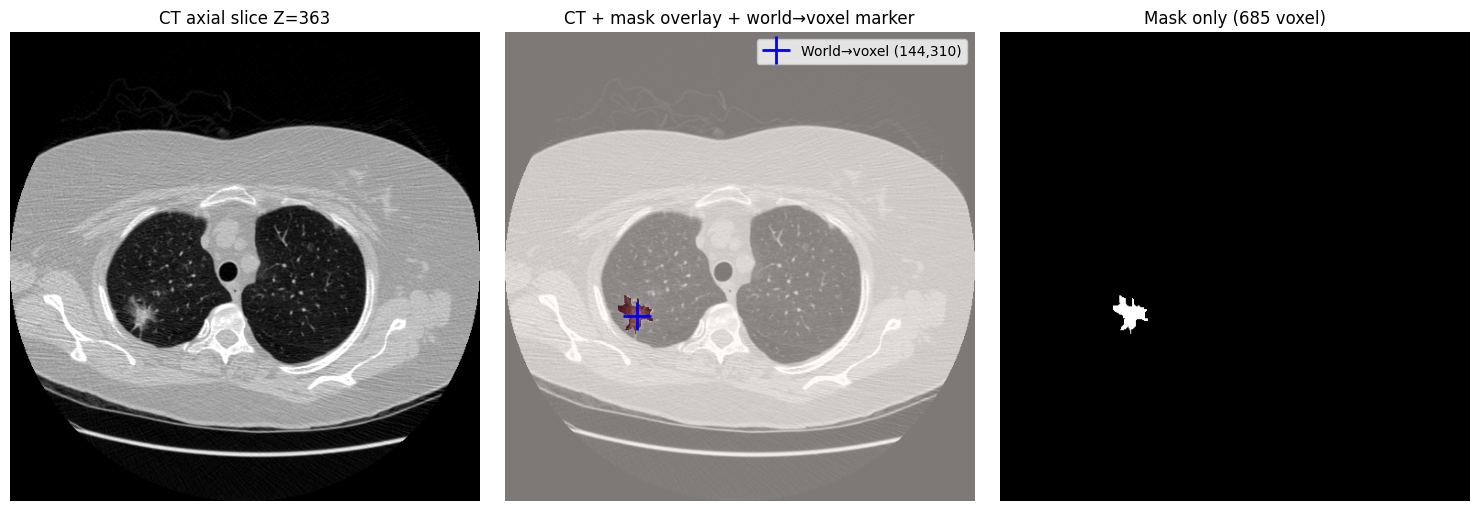


🔍 Beklenen: mavi + işareti mask ile çakışmalı. Çakışmıyorsa konvansiyon hatası var.


In [14]:
# En büyük mask'li bir malign nodül seç (debug için en görünür örnek)
candidates_for_viz = final_df[
    (final_df['malignancy_label'] == 1) &
    (final_df['has_mask'] == True)
].sort_values('mask_voxel_count', ascending=False)

if len(candidates_for_viz) == 0:
    print('⚠️ Görselleştirme için uygun nodul bulunamadı.')
else:
    sample = candidates_for_viz.iloc[0]
    seriesuid = sample['seriesuid']
    npz_path = npz_path_for(seriesuid)

    if npz_path is None:
        print(f'⚠️ NPZ bulunamadı: {seriesuid}')
    else:
        print(f'Sample: {seriesuid[:40]}...')
        print(f'  Malignancy mean: {sample["malignancy_mean"]:.2f} → label=malign')
        print(f'  Diameter: {sample["diameter_mm"]:.1f} mm')
        print(f'  Mask voxel: {sample["mask_voxel_count"]}')
        print(f'  World coord: ({sample["coordX"]:.1f}, {sample["coordY"]:.1f}, {sample["coordZ"]:.1f})')

        data = np.load(npz_path)
        scan = data['scan']        # (Z, Y, X) int16 HU
        origin = data['origin']    # ZYX
        spacing = data['spacing']  # ZYX
        print(f'  Scan shape: {scan.shape}, spacing: {spacing}, origin: {origin}')

        # World → voxel (NPZ ZYX)
        vz = int(round((sample['coordZ'] - origin[0]) / spacing[0]))
        vy = int(round((sample['coordY'] - origin[1]) / spacing[1]))
        vx = int(round((sample['coordX'] - origin[2]) / spacing[2]))
        print(f'  Voxel (Z,Y,X): ({vz}, {vy}, {vx})')
        in_bounds = (0 <= vz < scan.shape[0] and 0 <= vy < scan.shape[1] and 0 <= vx < scan.shape[2])
        print(f'  In bounds: {in_bounds}')

        # Mask'ı H5'ten yükle, full volume'a yerleştir
        with h5py.File(MASKS_H5, 'r') as h5f:
            grp = h5f[sample['mask_key']]
            mask_local = grp['mask'][:]
            zs, ze = grp.attrs['z_start'], grp.attrs['z_stop']
            ys, ye = grp.attrs['y_start'], grp.attrs['y_stop']
            xs, xe = grp.attrs['x_start'], grp.attrs['x_stop']

        full_mask = np.zeros(scan.shape, dtype=bool)
        full_mask[zs:ze, ys:ye, xs:xe] = mask_local.astype(bool)

        # Bbox merkezinden axial slice çek (world coord'dan değil, bbox'tan — daha güvenilir)
        z_center = (zs + ze) // 2
        scan_slice = np.clip(scan[z_center], -1000, 400)  # lung window display

        fig, axes = plt.subplots(1, 3, figsize=(15, 5))
        axes[0].imshow(scan_slice, cmap='gray')
        axes[0].set_title(f'CT axial slice Z={z_center}')
        axes[0].axis('off')

        axes[1].imshow(scan_slice, cmap='gray')
        axes[1].imshow(full_mask[z_center], cmap='Reds', alpha=0.5)
        # World coord'a göre marker'ı çiz (mask ile eşleşmeli)
        if in_bounds and abs(vz - z_center) <= 5:
            axes[1].plot(vx, vy, 'b+', markersize=20, markeredgewidth=2,
                       label=f'World→voxel ({vx},{vy})')
            axes[1].legend()
        axes[1].set_title('CT + mask overlay + world→voxel marker')
        axes[1].axis('off')

        axes[2].imshow(full_mask[z_center], cmap='gray')
        axes[2].set_title(f'Mask only ({full_mask[z_center].sum()} voxel)')
        axes[2].axis('off')

        plt.tight_layout()
        plt.show()

        print('\n🔍 Beklenen: mavi + işareti mask ile çakışmalı. Çakışmıyorsa konvansiyon hatası var.')